In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import loguniform, uniform
from sklearn.datasets import fetch_california_housing
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import (
    LinearRegression, Lasso, LassoCV, RidgeCV, Ridge, SGDRegressor
)
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
)
from sklearn.model_selection import (
    cross_validate, cross_val_score, train_test_split, validation_curve,
    ShuffleSplit, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
pd.options.display.float_format = '{:.2f}'.format

In [3]:
california_housing = fetch_california_housing(as_frame=True)
type(california_housing)
list(california_housing)

sklearn.utils._bunch.Bunch

['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR']

In [4]:
np.random.seed(306)

In [5]:
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
cv

ShuffleSplit(n_splits=10, random_state=42, test_size=0.2, train_size=None)

In [6]:
# fetch dataset
features, labels = fetch_california_housing(as_frame=True, return_X_y=True)

type(features)
type(labels)

features.shape
labels.shape

pandas.core.frame.DataFrame

pandas.core.series.Series

(20640, 8)

(20640,)

In [7]:
# train-test split
com_train_features, test_features, com_train_labels, test_labels = train_test_split(
    features, labels, random_state=42)

com_train_features.shape
com_train_labels.shape

test_features.shape
test_labels.shape

(15480, 8)

(15480,)

(5160, 8)

(5160,)

In [8]:
# train --> train + dev split
train_features, dev_features, train_labels, dev_labels = train_test_split(
    com_train_features, com_train_labels, random_state=42)

train_features.shape
train_labels.shape

dev_features.shape
dev_labels.shape

(11610, 8)

(11610,)

(3870, 8)

(3870,)

## Linear regression with normal equation

In [9]:
lin_reg_pipeline = Pipeline([("feature_scaling", StandardScaler()),
                             ("lin_reg", LinearRegression())])

lin_reg_cv_results = cross_validate(lin_reg_pipeline,
                                    com_train_features,
                                    com_train_labels,
                                    cv=cv,
                                    scoring="neg_mean_absolute_error",
                                    return_train_score=True,
                                    return_estimator=True)

lin_reg_train_error = -1 * lin_reg_cv_results['train_score']
lin_reg_test_error = -1 * lin_reg_cv_results['test_score']

print(f"Mean absolute error of linear regression model on the train set:\n"
      f"{lin_reg_train_error.mean():.3f} +/- {lin_reg_train_error.std():.3f}")
print(f"Mean absolute error of linear regression model on the test set:\n"
      f"{lin_reg_test_error.mean():.3f} +/- {lin_reg_test_error.std():.3f}")

Mean absolute error of linear regression model on the train set:
0.530 +/- 0.002
Mean absolute error of linear regression model on the test set:
0.527 +/- 0.008


## Linear regression with SGD

In [11]:
sgd_reg_pipeline = Pipeline([("feature_scaling", StandardScaler()),
                             ("sgd_reg", SGDRegressor(
                                 max_iter=int(np.ceil(
                                     1e6/com_train_features.shape[0])),
                                 early_stopping=True,
                                 eta0=1e-4,
                                 learning_rate='constant',
                                 tol=1e-5,
                                 validation_fraction=0.1,
                                 n_iter_no_change=5,
                                 average=10,
                                 random_state=42))])

sgd_reg_cv_results = cross_validate(sgd_reg_pipeline,
                                    com_train_features,
                                    com_train_labels,
                                    cv=cv,
                                    scoring="neg_mean_absolute_error",
                                    return_train_score=True,
                                    return_estimator=True)

sgd_train_error = -1 * sgd_reg_cv_results['train_score']
sgd_test_error = -1 * sgd_reg_cv_results['test_score']

print(f"Mean absolute error of SGD regression model on the train set:\n"
      f"{sgd_train_error.mean():.3f} +/- {sgd_train_error.std():.3f}")
print(f"Mean absolute error of SGD regression model on the test set:\n"
      f"{sgd_test_error.mean():.3f} +/- {sgd_test_error.std():.3f}")

Mean absolute error of SGD regression model on the train set:
0.534 +/- 0.013
Mean absolute error of SGD regression model on the test set:
0.530 +/- 0.010


## Polynomial regression

In [12]:
poly_reg_pipeline = Pipeline([("poly", PolynomialFeatures(degree=2)),
                              ("feature_scaling", StandardScaler()),
                              ("lin_reg", LinearRegression())])

poly_reg_cv_results = cross_validate(poly_reg_pipeline,
                                     com_train_features,
                                     com_train_labels,
                                     cv=cv,
                                     scoring="neg_mean_absolute_error",
                                     return_train_score=True,
                                     return_estimator=True)

poly_reg_train_error = -1 * poly_reg_cv_results['train_score']
poly_reg_test_error = -1 * poly_reg_cv_results['test_score']

print(f"Mean absolute error of linear regression model on the train set:\n"
      f"{poly_reg_train_error.mean():.3f} +/- {poly_reg_train_error.std():.3f}")
print(f"Mean absolute error of linear regression model on the test set:\n"
      f"{poly_reg_test_error.mean():.3f} +/- {poly_reg_test_error.std():.3f}")

Mean absolute error of linear regression model on the train set:
0.461 +/- 0.003
Mean absolute error of linear regression model on the test set:
0.485 +/- 0.030


Instead of using all polynomial feature, we use only interaction feature terms in polynomial model and train the linear regression model.

In [13]:
poly_reg_pipeline = Pipeline([("poly", PolynomialFeatures(degree=2, interaction_only=True)),
                              ("feature_scaling", StandardScaler()),
                              ("lin_reg", LinearRegression())])

poly_reg_cv_results = cross_validate(poly_reg_pipeline,
                                     com_train_features,
                                     com_train_labels,
                                     cv=cv,
                                     scoring="neg_mean_absolute_error",
                                     return_train_score=True,
                                     return_estimator=True)

poly_reg_train_error = -1 * poly_reg_cv_results['train_score']
poly_reg_test_error = -1 * poly_reg_cv_results['test_score']

print(f"Mean absolute error of polynomial regression model of degree 2 on the train set:\n"
      f"{poly_reg_train_error.mean():.3f} +/- {poly_reg_train_error.std():.3f}")
print(f"Mean absolute error of polynomial regression model of degree 2 on the test set:\n"
      f"{poly_reg_test_error.mean():.3f} +/- {poly_reg_test_error.std():.3f}")

Mean absolute error of polynomial regression model of degree 2 on the train set:
0.478 +/- 0.003
Mean absolute error of polynomial regression model of degree 2 on the test set:
0.497 +/- 0.024


Here we specify a list of values that we want to try for polynomial degree and specify it as a parameter in validation_curve.

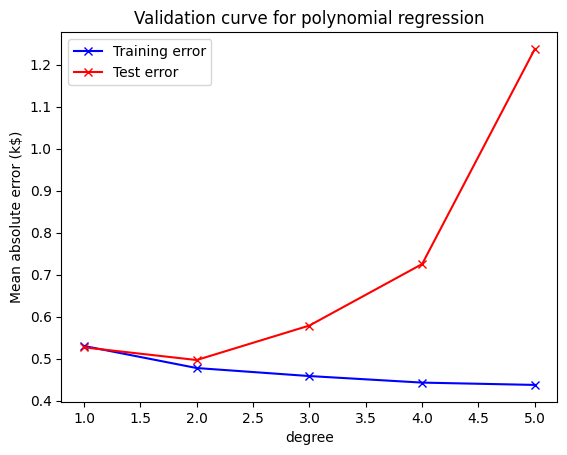

In [15]:
degree = [1, 2, 3, 4, 5]
train_scores, test_scores = validation_curve(
    poly_reg_pipeline, com_train_features, com_train_labels, param_name="poly__degree",
    param_range=degree, cv=cv, scoring="neg_mean_absolute_error",
    n_jobs=2)

train_errors, test_errors = -train_scores, -test_scores
_ = plt.plot(degree, train_errors.mean(axis=1), 'b-x', label="Training error")
_ = plt.plot(degree, test_errors.mean(axis=1), 'r-x', label="Test error")
_ = plt.legend()

_ = plt.xlabel("degree")
_ = plt.ylabel("Mean absolute error (k$)")
_ = plt.title("Validation curve for polynomial regression")

## Ridge regression

In [16]:
ridge_reg_pipeline = Pipeline([("poly", PolynomialFeatures(degree=2)),
                              ("feature_scaling", StandardScaler()),
                              ("ridge", Ridge(alpha=0.5))])

ridge_reg_cv_results = cross_validate(ridge_reg_pipeline,
                                      com_train_features,
                                      com_train_labels,
                                      cv=cv,
                                      scoring="neg_mean_absolute_error",
                                      return_train_score=True,
                                      return_estimator=True)

ridge_reg_train_error = -1 * ridge_reg_cv_results['train_score']
ridge_reg_test_error = -1 * ridge_reg_cv_results['test_score']

print(f"Mean absolute error of ridge regression model (alpha=0.5) on the train set:\n"
      f"{ridge_reg_train_error.mean():.3f} +/- {ridge_reg_train_error.std():.3f}")
print(f"Mean absolute error of ridge regression model (alpha=0.5) on the test set:\n"
      f"{ridge_reg_test_error.mean():.3f} +/- {ridge_reg_test_error.std():.3f}")

Mean absolute error of ridge regression model (alpha=0.5) on the train set:
0.481 +/- 0.003
Mean absolute error of ridge regression model (alpha=0.5) on the test set:
0.487 +/- 0.006


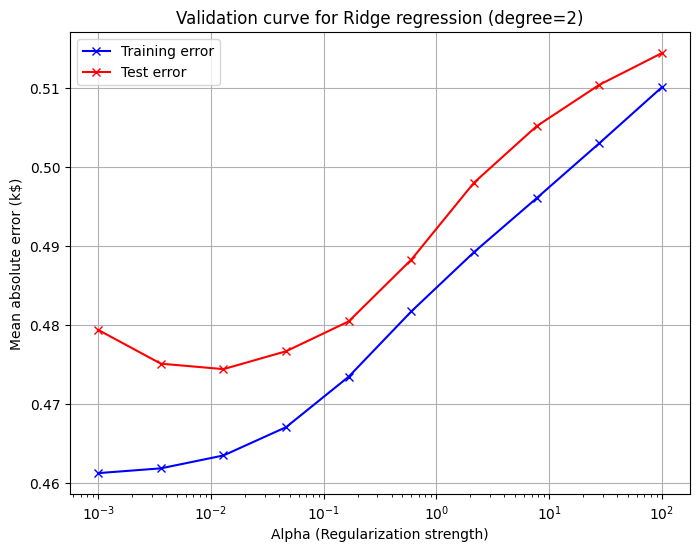

In [ ]:
# 1. Define a range of alpha values to test.
# Using a logarithmic scale is usually best for alpha (e.g., 0.001 to 100)
alphas = np.logspace(-3, 2, 10)

# 2. Compute the validation curve
# Note the param_name "ridge__alpha" to reach inside the pipeline
train_scores, test_scores = validation_curve(
    ridge_reg_pipeline, com_train_features, com_train_labels,
    param_name="ridge__alpha",
    param_range=alphas,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=2
)

# 3. Convert scores to positive MAE errors
train_errors, test_errors = -train_scores, -test_scores

# 4. Plot the results
_ = plt.figure(figsize=(8, 6))
_ = plt.semilogx(alphas, train_errors.mean(axis=1), 'b-x', label="Training error")
_ = plt.semilogx(alphas, test_errors.mean(axis=1), 'r-x', label="Test error")

_ = plt.xlabel("Alpha (Regularization strength)")
_ = plt.ylabel("Mean absolute error")
_ = plt.title("Validation curve for Ridge regression (degree=2)")
_ = plt.legend()
_ = plt.grid(True)

The X-axis: I used plt.semilogx because alpha values often span orders of magnitude (0.01, 0.1, 1, 10). A linear scale would squish all the small values together.

In [21]:
# 1. Calculate the average test error for each alpha across all CV folds
mean_test_errors = test_errors.mean(axis=1)

# 2. Find the index of the alpha that gave the minimum mean error
best_index = np.argmin(mean_test_errors)

# 3. Retrieve the corresponding alpha value
best_alpha = alphas[best_index]
best_error = mean_test_errors[best_index]

print(f"The best alpha value is: {best_alpha:.4f}")
print(f"Minimum Mean Absolute Error: {best_error:.3f}")

The best alpha value is: 0.0129
Minimum Mean Absolute Error: 0.474


In [22]:
ridge_reg_pipeline = Pipeline([("poly", PolynomialFeatures(degree=2)),
                              ("feature_scaling", StandardScaler()),
                              ("ridge", Ridge(alpha=0.0129))])

ridge_reg_cv_results = cross_validate(ridge_reg_pipeline,
                                      com_train_features,
                                      com_train_labels,
                                      cv=cv,
                                      scoring="neg_mean_absolute_error",
                                      return_train_score=True,
                                      return_estimator=True)

ridge_reg_train_error = -1 * ridge_reg_cv_results['train_score']
ridge_reg_test_error = -1 * ridge_reg_cv_results['test_score']

print(f"Mean absolute error of ridge regression model (alpha=0.5) on the train set:\n"
      f"{ridge_reg_train_error.mean():.3f} +/- {ridge_reg_train_error.std():.3f}")
print(f"Mean absolute error of ridge regression model (alpha=0.5) on the test set:\n"
      f"{ridge_reg_test_error.mean():.3f} +/- {ridge_reg_test_error.std():.3f}")

Mean absolute error of ridge regression model (alpha=0.5) on the train set:
0.463 +/- 0.004
Mean absolute error of ridge regression model (alpha=0.5) on the test set:
0.474 +/- 0.014


## HPT for ridge regularization rate (using RidgeCV)

In [23]:
alpha_list = np.logspace(-4, 0, num=20)
ridge_reg_pipeline = Pipeline([("poly", PolynomialFeatures(degree=2)),
                              ("feature_scaling", StandardScaler()),
                              ("ridge_cv", RidgeCV(alphas=alpha_list,
                                                   cv=cv,
                                                   scoring="neg_mean_absolute_error"))])
ridge_reg_cv_results = ridge_reg_pipeline.fit(com_train_features, com_train_labels)

In [24]:
print("The score with the best alpha is:",
      f"{ridge_reg_cv_results[-1].best_score_:.3f}")
print("The error with the best alpha is:",
      f"{-ridge_reg_cv_results[-1].best_score_:.3f}")

The score with the best alpha is: -0.473
The error with the best alpha is: 0.473


In [25]:
print("The best value for alpha:", ridge_reg_cv_results[-1].alpha_)

The best value for alpha: 0.007847599703514606


In [27]:
ridge_reg_pipeline = Pipeline([("poly", PolynomialFeatures(degree=2)),
                              ("feature_scaling", StandardScaler()),
                              ("ridge", Ridge(alpha=0.00784))])

ridge_reg_cv_results = cross_validate(ridge_reg_pipeline,
                                      com_train_features,
                                      com_train_labels,
                                      cv=cv,
                                      scoring="neg_mean_absolute_error",
                                      return_train_score=True,
                                      return_estimator=True)

ridge_reg_train_error = -1 * ridge_reg_cv_results['train_score']
ridge_reg_test_error = -1 * ridge_reg_cv_results['test_score']

print(f"Mean absolute error of ridge regression model (alpha=0.5) on the train set:\n"
      f"{ridge_reg_train_error.mean():.3f} +/- {ridge_reg_train_error.std():.3f}")
print(f"Mean absolute error of ridge regression model (alpha=0.5) on the test set:\n"
      f"{ridge_reg_test_error.mean():.3f} +/- {ridge_reg_test_error.std():.3f}")

Mean absolute error of ridge regression model (alpha=0.5) on the train set:
0.463 +/- 0.004
Mean absolute error of ridge regression model (alpha=0.5) on the test set:
0.474 +/- 0.015


## Ridge HPT through `GridSearchCV`

In [38]:
ridge_grid_pipeline = Pipeline([("poly", PolynomialFeatures(degree=2)),
                                ("feature_scaling", StandardScaler()),
                                ("ridge", Ridge())])

param_grid = {'poly__degree': (1, 2, 3),
              'ridge__alpha': np.logspace(-4, 0, num=20)}

ridge_grid_search = GridSearchCV(ridge_grid_pipeline,
                                 param_grid=param_grid,
                                 n_jobs=2,
                                 cv=cv,
                                 scoring="neg_mean_absolute_error",
                                 return_train_score=True)

ridge_grid_search.fit(com_train_features, com_train_labels)

,estimator,"Pipeline(step...e', Ridge())])"
,param_grid,"{'poly__degree': (1, ...), 'ridge__alpha': array([1.0000...00000000e+00])}"
,scoring,'neg_mean_absolute_error'
,n_jobs,2
,refit,True
,cv,ShuffleSplit(...ain_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,degree,2


In [39]:
mean_train_error = -1 * \
    ridge_grid_search.cv_results_['mean_train_score'][ridge_grid_search.best_index_]
mean_test_error = -1 * \
    ridge_grid_search.cv_results_['mean_test_score'][ridge_grid_search.best_index_]
std_train_error = ridge_grid_search.cv_results_['std_train_score'][ridge_grid_search.best_index_]
std_test_error = ridge_grid_search.cv_results_['std_train_score'][ridge_grid_search.best_index_]

print(f"Best Mean absolute error of polynomial ridge regression model on the train set:\n"
      f"{mean_train_error:.3f} +/- {std_train_error:.3f}")
print(f"Mean absolute error of polynomial ridge regression model on the test set:\n"
      f"{mean_test_error:.3f} +/- {std_test_error:.3f}")

Best Mean absolute error of polynomial ridge regression model on the train set:
0.463 +/- 0.004
Mean absolute error of polynomial ridge regression model on the test set:
0.474 +/- 0.004


In [40]:
print("Mean cross validated score of the best estimator is: ", ridge_grid_search.best_score_)
print("Mean cross validated error of the best estimator is: ", -ridge_grid_search.best_score_)

Mean cross validated score of the best estimator is:  -0.4738651177003649
Mean cross validated error of the best estimator is:  0.4738651177003649


In [41]:
print("The best parameter value is:", ridge_grid_search.best_params_)

The best parameter value is: {'poly__degree': 2, 'ridge__alpha': np.float64(0.007847599703514606)}
